# Primera Práctica: Predicción de Subscripción a un Producto Bancario.

### Somos Lidia Valera López y Ana Díaz Jiménez del grupo 81
### Correos: 100522236@alumnos.uc3m.es y 100522155@alumnos.uc3m.es, respectivamente. 
### NIAS: 100522236 y 100522155, respectivamente
### Nuestra semilla es la de la alumna Lidia Valera López, por lo que nuestro bank es el 9 (3+6)

## 1. EDA Simplificado

### Cargar los datos

Lo primero que hacemos es cargar nuestros datos y además mostraremos las primeras filas del DataFrame

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Definimos nuestra variable NIA con uno de nuestros NIAS, en nuestro caso el de Lidia Valera López
NIA = 100522236
# Cargamos los datos
df = pd.read_pickle("bank_09.pkl") 

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Número de instancias y variables

In [2]:
n_instancias, n_variables = df.shape

print(f"Número de instancias: {n_instancias}")
print(f"Número de variables: {n_variables}")

Número de instancias: 11000
Número de variables: 17


### Tipo de variables

A continuación obersavermos si las variables son numéricas, categóricas u ordinales

In [ ]:
# Definimos el target
target = "deposit"

# Vemos en el DataFrame que la variable "education" es ordinal, por lo que la incluimos en la lista de variables ordinales
ordinal_vars = ["education"]

# Detectamos variables numéricas
num_vars = df.select_dtypes(include=[np.number]).columns.tolist()

# Detectamos variables booleanas (contienen yes/no, Yes/No o True/False)
bool_vars = [col for col in df.columns if col != target and df[col].dropna().isin(['yes','no','Yes','No',True,False]).all()]

# Detectamos variables categóricas
cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Quitamos las columnas ordinales de las categóricas
cat_vars = [var for var in cat_vars if var not in ordinal_vars]

# Excluimos booleanas de categóricas y quitamos tambien la variable target de las categóricas
cat_vars = [var for var in cat_vars if var not in bool_vars and var != target]

# Mostramos resultados
print(f"Variables numéricas: {num_vars}")
print(f"Variables categóricas: {cat_vars}")
print(f"Variables ordinales: {ordinal_vars}")
print(f"Variables booleanas: {bool_vars}")

# Además comprobamos que no nos dejemos ninguna (+1 de la variable target)
total_detectadas = len(num_vars) + len(bool_vars) + len(cat_vars) + len(ordinal_vars) + 1
print(f"\nTotal variables detectadas: {total_detectadas} (de {df.shape[1]})")


Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'contact', 'month', 'poutcome']
Variables ordinales: ['education']
Variables booleanas: ['default', 'housing', 'loan']

Total variables detectadas: 17 (de 17)


Vemos de que tipo son todas nuestras variables y si las sumamos comprobamos que efectivamente hay 17, como habiamos visto en el apartado anterior. Además, separamos nuestra variable deposit (el target) ya que no es un atributo (feature) y nos podría causar data leakage ya que es la variable que queremos predecir

### Cardinalidad de variables categóricas

Comprobamos las variables categóricas con alta cardinalidad, que son las que tienen mas de 10 valores únicos

In [ ]:
for var in cat_vars:
    if df[var].nunique() > 10:
        print(f"La variable {var} tiene alta cardinalidad: {df[var].nunique()} valores únicos")

job con alta cardinalidad: 12 valores únicos
month con alta cardinalidad: 12 valores únicos


Vemos que tanto la vaiable job como la variable month tiene una alta cardinalidad

### Variables con valores faltantes

In [ ]:
# Detectamos valores nulos reales (NaN) 
nulos = df.isnull().sum() 
nulos = nulos[nulos > 0]
if not nulos.empty:
    print("Variables con nulos (NaN):\n", nulos)
else:
    print("No hay nulos (NaN) en el dataset.")

# Tambien detectamos valores nulos pero ahora en formato texto (unknown, None, etc.)
busqueda_nulos = ['unknown', 'None', 'none', 'null']

for col in df.select_dtypes(include=['object']):
    # Extraemos los valores únicos de la columna 
    valores_unicos = df[col].unique()
    # Comprobamos si alguno de los valores de busqueda_nulos está presente en los valores únicos de la columna
    encontrados = [v for v in busqueda_nulos if v in valores_unicos]
    
    if encontrados:
        print(f"La variable '{col}' tiene valores de tipo nulo/desconocido: {encontrados}")

Variables con nulos (NaN):
 job         97
marital    282
dtype: int64
La variable 'job' tiene valores de tipo nulo/desconocido: ['unknown']
La variable 'education' tiene valores de tipo nulo/desconocido: ['unknown']
La variable 'contact' tiene valores de tipo nulo/desconocido: ['unknown']
La variable 'poutcome' tiene valores de tipo nulo/desconocido: ['unknown']


Estos valores nulos (NaN) son importantes porque al entrenar un modelo con KNN o un Árbol, el código se detendrá y nos dará un error, ya que Scikit-Learn no sabe que hacer con estos valores. Además, los valores "unknown" pueden engañar al modelo.

Es por esto que en a fase de preprocesamiento, usaremos una estrategia de imputación para las variables con pocos nulos como job o marital. Para variables como poutcome donde parece que hay muchos valores "unknown" analizaremos si merece la pena mantener esa variable o si este valor aporta realmente información por si mismo.

### Columnas constantes

In [26]:
print("Frecuencias de los valores únicos:")
for var in df.columns:
    value = df[var].value_counts().max() / len(df)
    print(f"{var}: {value:.2f}")
    if value > 0.85:
        print(f"{var} es una variable muy constante")
    if value == 1.0:
        print(f"{var} es una variable constante")
constantes = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes:", constantes)
# No se han encontrado variables constantes.

Frecuencias de los valores únicos:
age: 0.04
job: 0.23
marital: 0.56
education: 0.49
default: 0.98
default es una variable muy constante
balance: 0.07
housing: 0.53
loan: 0.87
loan es una variable muy constante
contact: 0.72
day: 0.05
month: 0.25
duration: 0.00
campaign: 0.43
pdays: 0.75
previous: 0.75
poutcome: 0.75
deposit: 0.53
Columnas constantes: []


No tenemos columnas constantes, porque no hay ninguna que tengan frecuencia máxima = 1.0 ( es decir, que todos los valores son iguales), pero las columnas de default y loan son muy constantes, ya que tienen un 85% de un valor, pero no son estrictamente constantes. Si hubiera alguna columna constante, deberia eliminarse ya que no aportan información al modelo, pero no es el caso

### Columnas tipo ID

In [25]:
posibles_id = [col for col in df.columns if df[col].nunique() == len(df)]
print("Columnas tipo ID:", posibles_id)

if posibles_id == []:
    print("No se han encontrado variables que podrían ser IDs (todos los valores son únicos).")

Columnas tipo ID: []
No se han encontrado variables que podrían ser IDs (todos los valores son únicos).


Como podemos ver, no hay ninguna columna que sea tipo ID

### Tipo de problema

Ahora vemos si es un problema de clasificación o regresión. Para ello nos fijaremos en la variable deposit que es la variable objetivo

In [ ]:
target = "deposit"
print(df[target].dtype)
print(df[target].nunique(), "valores únicos")
df["deposit"].value_counts()

object
2 valores únicos


deposit
no     5780
yes    5220
Name: count, dtype: int64

Como vemos arriba, el target presenta dos valores únicos lo que supone un problema de clasificación binaria.

Además, como la variable target toma valores categóricos (yes/no) será necesario realizar una codificación (Encoding) para tranformarlo en valores numéricos (0 y 1) antes de entrenar los modelos, ya que los modelos no entienden estas palabras.

### ¿Está balanceado?

A continuación, vamos a ver si la variable deposit está balanceada

deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64


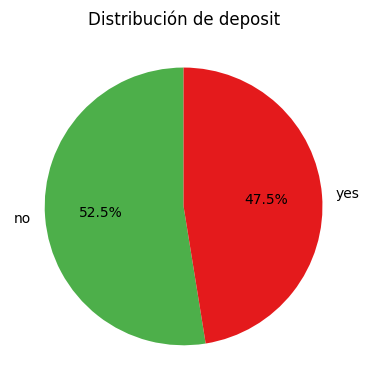

In [28]:
target = "deposit"
props = df[target].value_counts(normalize=True)

print(props)

# Comprobamos que no haya mas de un 70% de datos que pertenecen a una sola clase, ya que significaria que esta desbalanceado
if props.iloc[0] > 0.70:
    print(f"El target '{target}' está desbalanceado: {props[0]:.2f} de la clase mayoritaria.")

# Gráfico pie para visualizar la distribución del target
plt.figure(figsize=(4, 4))
props.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4daf4a", "#e41a1c"],
    legend=False,
    ylabel=""
)
plt.title("Distribución de deposit")
plt.tight_layout()
plt.show()

Como observamos en el gráfico, los datos estan balanceados, ya que hay un 52,2% de "no" y 47,5% de "yes". Por esto, no será necesiario aplicar técnicas de oversampling o undersampling para corregir desbalanceos.

### Analisis pdays

Estadísticas de pdays (todos los datos):
count    11000.000000
mean        52.054364
std        108.424506
min          0.000000
25%          0.000000
50%          0.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Los 10 valores más frecuentes de pdays:
pdays
0      8203
92      105
182      88
91       82
181      79
183      73
184      51
94       42
93       40
95       37
Name: count, dtype: int64
Número de clientes no contactados (pdays = 0): 8203
Número de clientes contactados (pdays != 0): 2797

Proporción de no contactados: 0.7457272727272727
Proporción de contactados: 0.25427272727272726


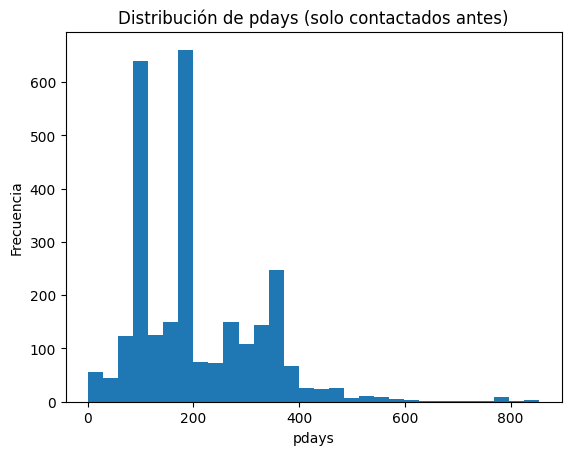

In [18]:
target = "pdays"

# Estadísticas generales
df["pdays"] = df["pdays"].replace(-1, 0)
print(f"Estadísticas de {target} (todos los datos):")
print(df[target].describe())
print()
print(f"Los 10 valores más frecuentes de {target}:")
print(df[target].value_counts().head(10))

# Número de clientes no contactados (pdays = 0) vs contactados (pdays != 0)
n_not_contacted = (df[target] == 0).sum()
n_contacted = (df[target] != 0).sum()

print("Número de clientes no contactados (pdays = 0):", n_not_contacted)
print("Número de clientes contactados (pdays != 0):", n_contacted)

# Opcional: comparación de proporciones
print()
print("Proporción de no contactados:", n_not_contacted / len(df))
print("Proporción de contactados:", n_contacted / len(df))

# Histograma de pdays para los contactados (pdays != 0)
import matplotlib.pyplot as plt

pdays_contacted = df.loc[df[target] != 0, target]
plt.hist(pdays_contacted, bins=30)
plt.title("Distribución de pdays (solo contactados antes)")
plt.xlabel("pdays")
plt.ylabel("Frecuencia")
plt.show() 


La variable pdays respresenta el número de días desde el último contacto con el cliente. El valor de -1 indica que el cliente no habia sido contactado previamete.
Gracias a los resultados, vemos que el 74,6% de los clientes nunca habían sido contactados antes, mientras que el 25,4% sí habian sido contactados. Por esto, la mediana es -1.
Para analizar la distribución real de los días desde el último contacto, se excluyeron los valores -1, ya que son un caso especial y si no lo hicieramos, el histograma quedaría dominado por este valor.

## 2. Decidir como se va a realizar la evaluación

Como hemos analizado anteriormente, la variable objetivo está bastante balanceada (52% vs 48%). Es por esto que hemos elegido como métrica principal el Accuracy. Además, es una métrica con una interpretación sencilla que nos dirá el porcentaje de predicciones totales correctas y en escenarios equilibrados como este, Accuracy es una medida fiable de rendimiento general.


Por otro lado, aunque los datos estén balanceados, desde una perspectiva de negocio como es el banco, no todos los errores tienen el mismo coste. Al banco le interesa no perder clientes potenciales (falsos negativos). Por lo que utilizaremos además Recall para la clase "yes", permitiéndonos asegurar que el modelo sea capaz de identificar a la mayor cantidad posible de clientes dispuestos a suscribir el depósito.

### División holdout (train/test)

In [19]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras y variable objetivo
x = df.drop(columns=["deposit"]) # Variables predictoras (features)
y = df["deposit"] # Variable objetivo (target)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3,
                                                    stratify=y,
                                                      random_state=42)

print("Tamaño del conjunto de entrenamiento:", x_train.shape[0])
print("Tamaño del conjunto de prueba:", x_test.shape[0])


Tamaño del conjunto de entrenamiento: 7333
Tamaño del conjunto de prueba: 3667


### Inner evaluation (crossvalidation)

Para la evaluación interna se empleará validación cruzada estratificada en 5 folds (Stratified 5-Fold CV), ya que garantiza que en cada una de las 5 particiones, la proporción de clientes que dicen 'yes' y 'no' no sea la misma que en el conjunto de entrenamiento, obtenemos una estimación mucho más fiable del rendimiento que si usáramos una única partición y porque nos ayudará a buscar los mejores hiperparámetros sin tocar el conjunto de test hasta el final.

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
#Diccionario para almacenar los resultados de las validaciones cruzadas
inner_scores = {}

Método de escalado con KNN, evaluación de alternativas

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier  # Cambiado a Classifier
from sklearn import metrics
target = "deposit"

# 1. Definir los escaladores a probar
scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}

# This variable will contain the 5 cross validation accuracies, one per iteration
scores = {'Standard': 0, 'MinMax': 0, 'Robust': 0}

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_vars),
        ('ord', OrdinalEncoder(), ordinal_vars)
    ]
)
print("Iteraciones de validación cruzada:")

for train_index, test_index in cv.split(x, y):
    # Getting the actual training and testing partitions out of the indices
    X_train, X_test = x.iloc[train_index,:], x.iloc[test_index,:]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    mean = 0

    for element in scalers:
        print(f"Evaluando escalar: {element}")
    # Training the model for this particular cross validation iteration
        pipe = Pipeline([
            ('prepro', preprocessor),
            ('scaler', scalers[element]),
            ('knn', KNeighborsClassifier())]
        )
        pipe.fit(X_train, y_train)
        y_test_pred = pipe.predict(X_test)
        accuracy_knn = metrics.accuracy_score(y_test, y_test_pred)

        # We add this accuracy to the list
        scores[element] += accuracy_knn
for element in scalers:
    scores[element] = scores[element]/3

# Transforming scores from list to numpy array (this is just a technicality)
scores_values = np.array(list(scores.values()))
scores_names = list(scores.keys())
for name, score in zip(scores_names, scores_values):
    print(f"Accuracy para escalar {name} : {score:.4f}")
    
print(f"Mejor escalar: {scores_names[np.argmax(scores_values)]}")


Iteraciones de validación cruzada:
Evaluando escalar: Standard
Evaluando escalar: MinMax
Evaluando escalar: Robust
Evaluando escalar: Standard
Evaluando escalar: MinMax
Evaluando escalar: Robust
Evaluando escalar: Standard
Evaluando escalar: MinMax
Evaluando escalar: Robust
Accuracy para escalar Standard : 0.7645
Accuracy para escalar MinMax : 0.7293
Accuracy para escalar Robust : 0.7983
Mejor escalar: Robust


Como medimos con accuracy, el mejor método es aquel cuya accuracy sea la mayor, por tanto lo mejor es Robust.

KNN y Árboles

Evaluación de hiperparámetros por omisión

In [65]:
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score



modelos = {
    'KNN (Mejor Scaler)': Pipeline([
        ('prepro', preprocessor),
        ('scaler', RobustScaler()), # El ganador de tu prueba anterior
        ('knn', KNeighborsClassifier()) # Parámetros por defecto (k=5)
    ]),
    'Árbol de Decisión': Pipeline([
        ('prepro', preprocessor),
        ('dt', DecisionTreeClassifier(random_state=42)) # Parámetros por defecto
    ])
}

for nombre, pipe in modelos.items():
    inicio = time.time() # Empezamos el cronómetro
    
    # Hacemos la validación cruzada para obtener la nota media
    scores = cross_val_score(pipe, X_train, y_train, cv=cv) 
    
    fin = time.time() # Paramos el cronómetro
    
    print(f"{nombre} - Accuracy: {scores.mean():.4f} - Tiempo: {fin - inicio:.4f}s")

KNN (Mejor Scaler) - Accuracy: 0.7847 - Tiempo: 0.7621s
Árbol de Decisión - Accuracy: 0.7754 - Tiempo: 0.7780s


El mejor modelo es el que tiene la mayor accuracy media. En este caso sería el modelo de KNN con el escalador RobustScaler, ya que obtuvo una mayor precisión en la validación cruzada en comparación con el Árbol de Decisión.

Interpretacion de como concebir decisiones a través de árboles poco profundos